In [1]:
#import packages and classes
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from GAKELM import GeneticELMRegressor #import genetic algorithm based ELM
from sklearn_extensions.extreme_learning_machines import elm
from keras.models import Sequential, load_model
from keras.layers import Dense
from keras.layers import LSTM #class for LSTM training
import os
from keras.layers import Dropout
from keras.callbacks import ModelCheckpoint
from keras.layers import Bidirectional #class for bidirectional LSTM as BILSTM
import math
from sklearn import svm

Using TensorFlow backend.
c:\users\joshi\appdata\local\programs\python\python37\lib\site-packages\tensorflow\python\framework\dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
c:\users\joshi\appdata\local\programs\python\python37\lib\site-packages\tensorflow\python\framework\dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
c:\users\joshi\appdata\local\programs\python\python37\lib\site-packages\tensorflow\python\framework\dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16

In [2]:
np.set_printoptions(suppress=True)

In [3]:
sc1 = MinMaxScaler(feature_range = (0, 1)) #use to normalize training data
sc2 = MinMaxScaler(feature_range = (0, 1)) #use to normalize label data

In [4]:
#interpolate function to deal with missing values and outliers
def interpolate_nans(X):
    """Overwrite NaNs with column value interpolations."""
    for j in range(X.shape[1]):
        mask_j = np.isnan(X[:,j])
        X[mask_j,j] = np.interp(np.flatnonzero(mask_j), np.flatnonzero(~mask_j), X[~mask_j,j])
    return X

In [5]:
#loading and displaying dataset values
dataset = pd.read_csv("Dataset/Dataset.csv")
dataset.fillna(0, inplace = True)
dataset

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,0.0,0.0,0.92,18.22,17.15,0.0,0.92,27.64,133.36,0.00,0.02,0.00,0.0,0
1,Ahmedabad,2015-01-02,0.0,0.0,0.97,15.69,16.46,0.0,0.97,24.55,34.06,3.68,5.50,3.77,0.0,0
2,Ahmedabad,2015-01-03,0.0,0.0,17.40,19.30,29.70,0.0,17.40,29.07,30.70,6.80,16.40,2.25,0.0,0
3,Ahmedabad,2015-01-04,0.0,0.0,1.70,18.48,17.97,0.0,1.70,18.59,36.08,4.43,10.14,1.00,0.0,0
4,Ahmedabad,2015-01-05,0.0,0.0,22.10,21.42,37.76,0.0,22.10,39.33,39.31,7.01,18.89,2.78,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
497,Ahmedabad,2016-05-12,0.0,0.0,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0
498,Ahmedabad,2016-05-13,0.0,0.0,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0
499,Ahmedabad,2016-05-14,0.0,0.0,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0
500,Ahmedabad,2016-05-15,0.0,0.0,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0


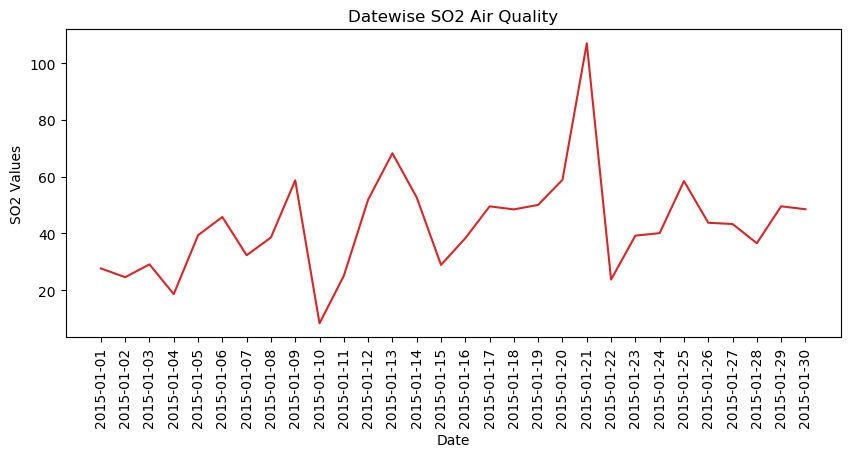

In [6]:
plt.figure(figsize=(10,4), dpi=100)
plt.plot(dataset.Date[0:30], dataset.SO2[0:30], color='tab:red')
plt.gca().set(title="Datewise SO2 Air Quality", xlabel='Date', ylabel="SO2 Values")
plt.xticks(rotation=90)
plt.show()

In [7]:
#dataset preprocessing such as normalization and extracting train and test data from dataset
#extracting X features and Y label from dataset
Y = dataset.values[:,2:3]
dataset.drop(['City'], axis = 1,inplace=True) #removing irrelevant columns
dataset.drop(['Date'], axis = 1,inplace=True)
dataset.drop(['PM2.5'], axis = 1,inplace=True)
dataset.drop(['AQI_Bucket'], axis = 1,inplace=True)
dataset = dataset.values
X = dataset[:,3:dataset.shape[1]-1]

#outlier and missing values removal using interpolation
X = interpolate_nans(X)

X = sc1.fit_transform(X)
Y = sc2.fit_transform(Y)
print("Normalized Training Features")
print(X)

Normalized Training Features
[[0.08532338 0.         0.00633086 ... 0.         0.00012222 0.        ]
 [0.08189055 0.         0.00667492 ... 0.0501499  0.03361036 0.10472222]
 [0.14776119 0.         0.11973576 ... 0.0926683  0.10022    0.0625    ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2)
print("Total records found in dataset  = "+str(X.shape[0]))
print("Total features found in dataset = "+str(X.shape[1]))
print("80% dataset for training : "+str(X_train.shape[0]))
print("20% dataset for testing  : "+str(X_test.shape[0]))

Total records found in dataset  = 502
Total features found in dataset = 8
80% dataset for training : 401
20% dataset for testing  : 101


In [9]:
mse = []
rmse = []

In [10]:
#function to calculate MSE and other metrics
def calculateMetrics(algorithm, predict, test_labels):
    predict = sc2.inverse_transform(np.abs(predict))
    test_label = sc2.inverse_transform(test_labels)
    predict = predict.ravel()
    test_label = test_label.ravel()
    mse_value = mean_squared_error(test_label, predict) / 100
    rmse_value = math.sqrt(mse_value)
    mse.append(mse_value)
    rmse.append(rmse_value)
    print(algorithm+" MSE  : "+str(mse_value))
    print(algorithm+" RMSE : "+str(rmse_value))
    plt.plot(test_label, color = 'red', label = 'Original Air Quality PM10')
    plt.plot(predict, color = 'green', label = 'Predicted Air Quality PM10')
    plt.title(algorithm+' Air Quality Prediction')
    plt.xlabel('Test Data')
    plt.ylabel('Predicted Air Quality')
    plt.legend()
    plt.show()

SVR MSE  : 11.021852760929061
SVR RMSE : 3.3199175834543033


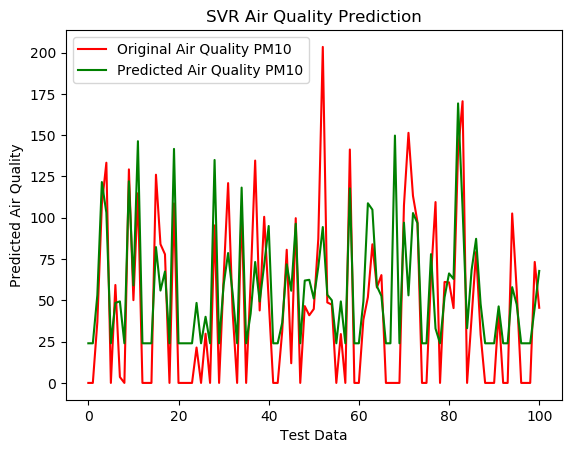

In [11]:
#now train existing SVM algorithm
svm_cls = svm.SVR()
svm_cls.fit(X_train, y_train.ravel())
predict = svm_cls.predict(X_test)
predict = predict.reshape(-1, 1)
calculateMetrics("SVR", predict, y_test)

GA-KELM MSE  : 6.327197941539761
GA-KELM RMSE : 2.5153922043172035


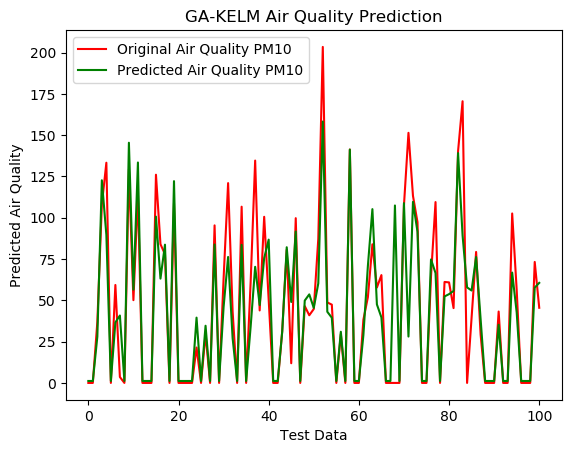

In [12]:
#creating object of genetic EML object by calling class
elm = GeneticELMRegressor()
elm.fit(X_train, y_train)#now train genetic elm on training data
predict = elm.predict(X_test) #perform prediction on test data
calculateMetrics("GA-KELM", predict, y_test)#calculate metrics


Proposed Bi-LSTM MSE  : 5.101824802803994
Proposed Bi-LSTM RMSE : 2.2587219401254317


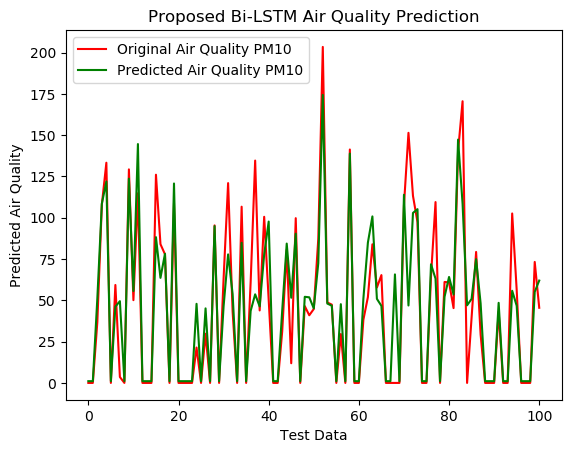

In [13]:
X_train1 = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test1 = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
#now train extension BI-LSTM algorithm
extension = Sequential()
#adding BILSTM 
extension.add(Bidirectional(LSTM(units = 50, input_shape = (X_train1.shape[1], X_train1.shape[2]), return_sequences=True)))
extension.add(Dropout(0.5))
#adding another layer to filter data
extension.add(Bidirectional(LSTM(units = 50, return_sequences = True)))
extension.add(Dropout(0.5))
#adding another layer
extension.add(Bidirectional(LSTM(units = 50, return_sequences = True)))
extension.add(Dropout(0.5))
extension.add(Bidirectional(LSTM(units = 50)))
extension.add(Dropout(0.5))
extension.add(Dense(units = 1))
extension.compile(optimizer = 'adam', loss = 'mean_squared_error')
if os.path.exists('model/extension_weights.hdf5') == False:
    model_check_point = ModelCheckpoint(filepath='model/extension_weights.hdf5', verbose = 1, save_best_only = True)
    extension.fit(X_train1, y_train, epochs = 250, batch_size = 4, validation_data=(X_test1, y_test), callbacks=[model_check_point], verbose=1)
else:
    extension = load_model('model/extension_weights.hdf5')
predict = extension.predict(X_test1)
calculateMetrics("Proposed Bi-LSTM", predict, y_test)

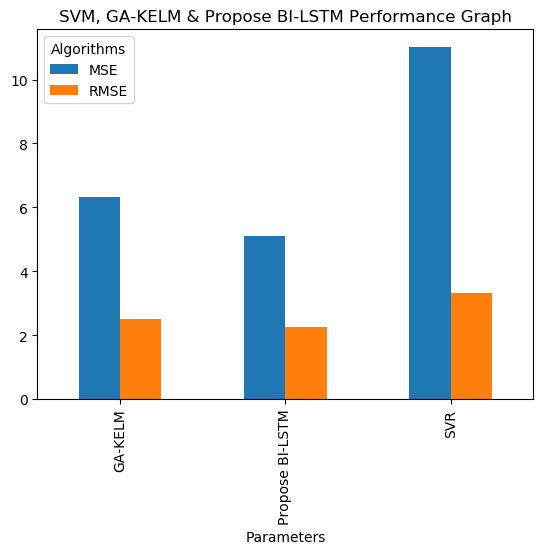

In [14]:
df = pd.DataFrame([['SVR','MSE',mse[0]],['SVR','RMSE',rmse[0]],
                   ['GA-KELM','MSE',mse[1]],['GA-KELM','RMSE',rmse[1]],
                   ['Propose BI-LSTM','MSE',mse[2]],['Propose BI-LSTM','RMSE',rmse[2]],
                  ],columns=['Parameters','Algorithms','Value'])
df.pivot("Parameters", "Algorithms", "Value").plot(kind='bar')
plt.title("SVM, GA-KELM & Propose BI-LSTM Performance Graph")
plt.show()

In [15]:
#showing all algorithms performance values
columns = ["Algorithm Name","MSE","RMSE"]
values = []
algorithm_names = ["SVR", "GA-KELM","Propose BI-LSTM"]
for i in range(len(algorithm_names)):
    values.append([algorithm_names[i],mse[i],rmse[i]])
    
temp = pd.DataFrame(values,columns=columns)
temp

,Algorithm Name,MSE,RMSE
0,SVR,11.021853,3.319918
1,GA-KELM,6.327198,2.515392
2,Propose BI-LSTM,5.101825,2.258722


In [16]:
#perform air quality prediction using extension BI-LSTM algorithm
dataset = pd.read_csv("Dataset/testData.csv")
dataset.fillna(0, inplace = True)
dataset.drop(['City'], axis = 1,inplace=True) #removing irrelevant columns
dataset.drop(['Date'], axis = 1,inplace=True)
dataset.drop(['PM2.5'], axis = 1,inplace=True)
dataset.drop(['AQI_Bucket'], axis = 1,inplace=True)
dataset = dataset.values
X = dataset[:,3:dataset.shape[1]-1]
#outlier and missing values removal using interpolation
X = interpolate_nans(X)
X1 = sc1.transform(X)
X1 = np.reshape(X1, (X1.shape[0], X1.shape[1], 1))
predict = extension.predict(X1) #perform air quality prediction using extension BI-LSTM extension object
predict = sc2.inverse_transform(predict)
for i in range(len(predict)):
    print("Test Data = "+str(X[i])+"=====> Predicted Air Quality : "+str(predict[i,0]))

Test Data = [37.73  0.    7.29 80.09 44.76  0.    0.    0.  ]=====> Predicted Air Quality : 72.341194
Test Data = [33.42  0.    8.92 54.28 47.42  0.    0.    0.27]=====> Predicted Air Quality : 45.065
Test Data = [26.86  0.    4.32 48.73 39.94  0.02  0.    3.55]=====> Predicted Air Quality : 54.90878
Test Data = [18.75  0.    1.41 35.91 56.15  0.    0.    3.31]=====> Predicted Air Quality : 55.852264
Test Data = [28.24  0.    6.34 66.58 53.14  9.7   9.63 16.49]=====> Predicted Air Quality : 87.42933
Test Data = [44.21  0.   14.19 65.91 31.88  7.72 17.46  2.51]=====> Predicted Air Quality : 82.72617
Test Data = [57.33  0.   18.18 80.43 40.11 11.29 24.35  3.35]=====> Predicted Air Quality : 118.35026
Test Data = [77.85  0.   37.49 99.72 36.47 17.   52.66  6.98]=====> Predicted Air Quality : 167.0433
Test Data = [44.87  0.   15.55 69.71 33.78 10.47 28.53  3.22]=====> Predicted Air Quality : 102.91522
Test Data = [47.31  0.   19.85 73.23 30.57 10.28 31.25  4.  ]=====> Predicted Air Quality